In [1]:
from IPython.display import SVG, display

import os
import MDAnalysis as md
import shaker

main_dir = os.getcwd()

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Basic Molecule Parameterization with `Shaker`

This tutorial demonstrates a simple workflow for parameterizing a molecule using `Shaker`.

You will learn how to **(1) map an atomistic (AA) molecule to a coarse-grained (CG) representation**, **(2) visualize and verify the resulting CG mapping**, **(3) obtain initial guesses for bonded parameters**, **(4) set up a simple CG simulation**, and **(5) iteratively refine the bonded parameters**.

This tutorial assumes a basic familiarity with **coarse-grained model parameterization**, particularly within the Martini framework.

In [2]:
author  = 'Luis Borges-Araujo'

itp_header = [
    f"; Parameterised by {author} @ ENS de Lyon, 2026.\n"
    "; Molecular name: \n",
    "; SMILES: \n",
]

## AA reference sims (already PBC treated and removed solvent.)
GRO = '../AA_references/BasicParam/AA.pdb'
XTC = '../AA_references/BasicParam/AA.xtc'
resname = "MOL"

### 1. Define the mapping and generate a CG reference trajectory

The first step in any parameterization workflow is defining the **mapping**
between the atomistic (AA) representation and the coarse-grained (CG) model.
At this stage you will also define **bead names** and assign provisional
**CG bead types**. These types are only an initial guess and can later be
refined by comparing the molecule's **partitioning behavior** with available
experimental or theoretical data.
This can be conveniently done using
[cgbuilder](https://lp0lp.github.io/cgbuilder/), which allows you to
interactively group AA atoms into CG beads and export the resulting mapping in
the **SHAKER format**.
SHAKER uses a simple dictionary to describe how atomistic atoms are grouped
into CG beads. This mapping dictionary is reused across SHAKER tools, including
trajectory mapping, SASA analysis, topology generation, and visualization.

```python
mapping = {
    "MOL": {
        "R1": {"type": "SX3",  "charge": 0, "atoms": ['Cl1','Cl1','C0B','C0B','C0A','C05']},
        "R2": {"type": "SX3",  "charge": 0, "atoms": ['C06','C06','C05','C08','Cl0','Cl0']},
        ...
    },
}
```

Each entry defines a CG bead:
* `"MOL"` – residue name in the atomistic system
* `"R1", "R2"` – CG bead names
* `"atoms"` – atom names mapped to that bead
* `"type"` *(optional)* – Martini bead type
* `"charge"` *(optional)* – bead charge

Bead coordinates are computed as the **center of geometry** of the listed atoms.
Atoms can appear multiple times to apply simple weighting:

```python
"atoms": ['Cl1','Cl1','C0B','C0B','C0A','C05']
```

Once the mapping is defined, `shaker.map_aa2cg` can be used to generate a
**CG-mapped trajectory** from the reference AA simulation. This mapped
trajectory serves as the reference from which bonded parameters will be derived.
After mapping, SHAKER prints a **mapping summary** for each residue, reporting
the number of heavy atoms, the beads produced (broken down by bead size
category), and whether the total bead/atom count is consistent:

```
Mapping summary
==================================================

Residue : MOL
  Heavy atoms in residue   : 22
  Beads produced           : 9 [0 regular, 4 small, 5 tiny]
  Bead/atom mismatch (weighted)    : +0  [OK]
```

The **bead/atom mismatch** field flags potential issues with the mapping, a
non-zero value (weighted by bead size) indicates that the number of atoms
per bead may be inconsistent with the chosen bead types, and the mapping
should be reviewed.

To visually confirm that the mapping is correct, SHAKER provides two rendering
utilities:
* `shaker.render_2dMapping` — visualize the atom-to-bead assignment in 2D
* `shaker.render_mapping` — inspect the mapping directly on the 3D structure

In [3]:
mapping = {
    ## resname
    "MOL": {
    ## bead name; type(opt.);   charge(opt.);         Mapping.
        "R1": {"type": "SX3",   "charge": 0,  "atoms": ['Cl1','Cl1','C0B','C0B','C0A','C05']},
        "R2": {"type": "SX3",   "charge": 0,  "atoms": ['C06','C06','C05','C08','Cl0','Cl0']},
        "R3": {"type": "TC5",   "charge": 0,  "atoms": ['C09','C09','C08','H0V','H0W','H0W','C0A','H0X']},
        "P1": {"type": "SP2",   "charge": 0,  "atoms": ['O04','C03','N02','H0U']},
        "R4": {"type": "TC5",   "charge": 0,  "atoms": ['C00','C0D','C0D','C0E','H0Y','H0Y']},
        "R5": {"type": "TN6a",  "charge": 0,  "atoms": ['C0E','N0F','N0F','C0G']},
        "R6": {"type": "TC5",   "charge": 0,  "atoms": ['C01','C01','H0T','H0T','C00','C0G']},
        "P2": {"type": "SP2",   "charge": 0,  "atoms": ['N0H','H0S','C0I','O0J']},
        "C1": {"type": "TC1",   "charge": 0,  "atoms": ['H0Q','H0R','C0K','C0M','C0M','H0N','H0O','H0P']},
    },
}
shaker.map_aa2cg(GRO, XTC, mapping)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


Mapping the trajectory:   0%|          | 0/2501 [00:00<?, ?it/s]

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/GRO.py:479: UserWarning: missing dimension - setting unit cell to zeroed box [0., 0., 0.]
  warnings.warn(wmsg)


Mapping log written to /local/lborge01/Param_Software_Testing/shaker_tests/SimpleParameterization/cg_mapped_mapping.log

Mapping summary

Residue : MOL
  Heavy atoms in residue   : 22
  Beads produced           : 9 [0 regular, 4 small, 5 tiny]
  Bead/atom mismatch (weighted)    : +0  [OK]



/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


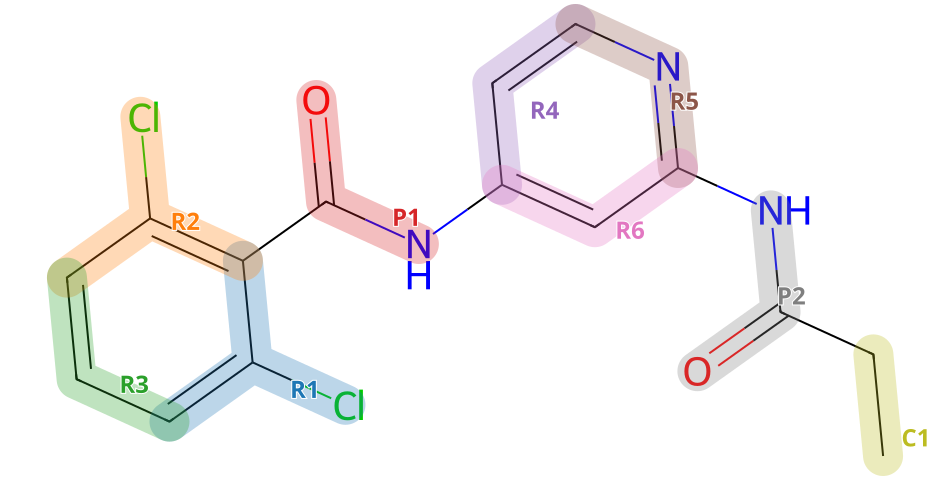

In [4]:
shaker.render_2dMapping(GRO, resname, mapping,
                               conn_r=20.0,font_size=24)
display(SVG("cg_overlay.svg"))

In [5]:
shaker.render_mapping('./cg_mapped.gro', './cg_mapped.xtc',
                           GRO, XTC, size='500px')

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


NGLWidget(frame=True, max_frame=2500)

### 2. Initial SASA calculations (AA vs mapped-CG)

A key step in Martini parameterization is ensuring that the **CG representation preserves the overall molecular shape** of the AA molecule. This is typically evaluated by comparing the **SASA (solvent accessible surface area)** and **Connolly surface** between the AA structure and the CG-mapped model.

Ideally, the **AA and CG-mapped SASA values should differ by less than ~5%** (differences up to ~10% are generally still acceptable). Larger deviations may indicate that the mapping does not accurately capture the molecule’s shape or volume, in which case the mapping should be revisited.

SASA can be calculated using `shaker.sasa.run_SASA`, which runs `gmx sasa` in the background. The resulting distributions can then be visualized using `shaker.plot.plot_sasa_dir()`.

It is important to note that **matching the molecular shape**, as reflected by the **Connolly surface**, is often as important—or even more important—than matching the SASA percentage itself. SASA values can be influenced by factors such as overall molecular size or slight differences in bead placement.

The Connolly surface can be visualized using `shaker.render.render_connely_surface`, which helps confirm that the CG mapping reproduces the overall geometry of the atomistic molecule.


/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/GRO.py:479: UserWarning: missing dimension - setting unit cell to zeroed box [0., 0., 0.]
  warnings.warn(wmsg)
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


CG_mapped model is 92.28% of AA.


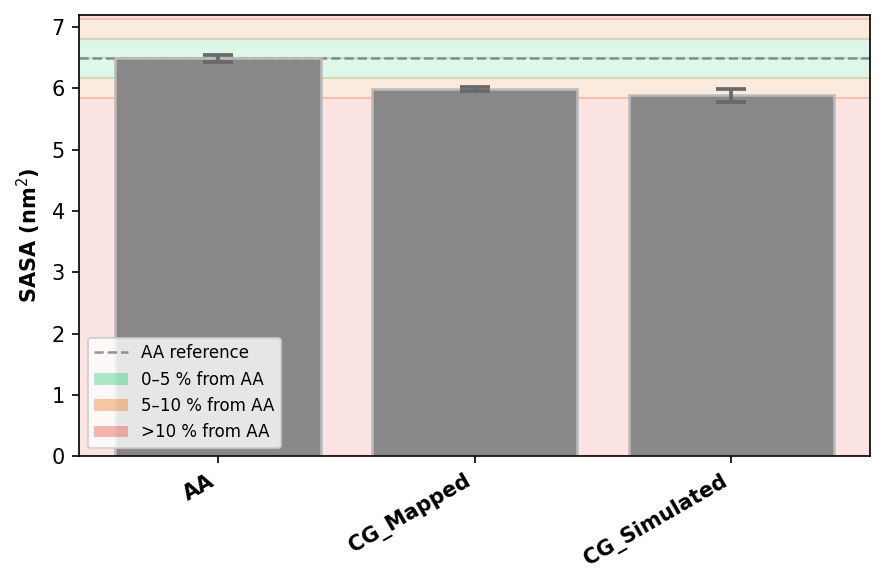

In [6]:
shaker.run_SASA('CG_Mapped',
                     f'{main_dir}/cg_mapped.gro', f'{main_dir}/cg_mapped.xtc', resname, 
                     isCG=True, mapping=mapping)
shaker.run_SASA('AA', GRO, XTC, resname)

fig, ax, sasa_values = shaker.plot_sasa_dir()

CG_over_AA_ratio = sasa_values[1][1] / sasa_values[0][1]
print(f"CG_mapped model is {CG_over_AA_ratio:.2%} of AA.")

In [7]:
shaker.render_connely_surface(size='500px')

no trajectory available


NGLWidget(frame=True)

### 3. Obtain initial bonded parameter guesses

In order to run our first CG simulation, we need an initial guess for the bonded parameters. At this stage, trying to parameterize everything at once is unnecessary and often leads to unstable simulations. It is usually best to begin with a minimal bonded model, including only the most important bonds and perhaps a few angles, and then progressively refine the model by adding additional terms if needed.

`shaker.estimator.bonded_estimator` provides a convenient way to generate these initial parameters directly from the CG-mapped reference trajectory produced earlier. The function measures the requested bonded distributions and estimates harmonic parameters from the resulting histograms.

We first specify the bonds and angles we want to include in the initial model, and then estimate the parameters directly from the mapped trajectory. However, `shaker.estimator.bonded_estimator` can also provide estimates for harmonic and improper dihedrals.

The estimator returns a GROMACS-formatted topology block containing `[ bonds ]`, `[ constraints ]`,  `[ angles ]`, and `[ dihedrals ]` sections that can be pasted directly into the molecule `.itp` file.

Very stiff bonds are automatically converted to constraints, since these interactions are typically better treated as fixed distances in Martini models. At this stage the parameters should be viewed as starting guesses rather than final values. The next steps of the workflow involve running short CG simulations and iteratively refining the bonded parameters by comparing the CG and reference distributions.

In [8]:
ang_tgts =  [
    ['R1', 'R2', 'R4'],
    ['R2', 'R4', 'R6'],
    ['R3', 'P1', 'R5'],
    ['R1', 'P1', 'R4'],
    ['R1', 'P1', 'R6'],
    ['C1', 'P2', 'R5'],
]

dist_tgts =[
            ['R1', 'R2'],
            ['R1', 'R3'],
            ['R2', 'R3'],
            ['R4', 'R5'],
            ['R4', 'R6'],
            ['R5', 'R6'],
            ['R1', 'P1'],
            ['R2', 'P1'],
            ['P1', 'R4'],
            ['P1', 'R6'],
            ['R5', 'P2'],
            ['R6', 'P2'],
            ['P2', 'C1'],
           ]  

harm_dihed_tgts =[
          ['R1', 'R2', 'R4', 'R6'],
          ['C1', 'P2', 'R5', 'R6'],
           ]  

imp_dihed_tgts = [
              ['R3', 'R1', 'R2', 'P1'],
              ['R5', 'R4', 'R6', 'P1'],
              ['R4', 'R6', 'R5', 'P2'],
]

u_aa = md.Universe(f'{main_dir}/cg_mapped.gro', f'{main_dir}/cg_mapped.xtc')
footer = shaker.bonded_estimator(u_aa, resname="MOL", 
                                 dist_tgts=dist_tgts, ang_tgts=ang_tgts, 
                                 harm_dihed_tgts=harm_dihed_tgts, imp_dihed_tgts=imp_dihed_tgts,
                                 use_indices=True)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


Measuring Bonded parameters:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
print(footer)

[ bonds ]
;  i    j  funct   length      force.c. ; beads
   1    4   1      0.284      17912.1 ; R1-P1
   2    4   1      0.284      17558.4 ; R2-P1
   4    5   1      0.302       8198.1 ; P1-R4
   4    7   1      0.280       8265.8 ; P1-R6
   6    8   1      0.293      14493.0 ; R5-P2
   7    8   1      0.276      10914.1 ; R6-P2
   8    9   1      0.254      18047.2 ; P2-C1

[ constraints ]
;  i    j  funct   length                ; beads
   1    2   1      0.308 ; R1-R2, turned into constraint because k=87151.2
   1    3   1      0.274 ; R1-R3, turned into constraint because k=37494.3
   2    3   1      0.274 ; R2-R3, turned into constraint because k=36638.1
   5    6   1      0.228 ; R4-R5, turned into constraint because k=74675.5
   5    7   1      0.266 ; R4-R6, turned into constraint because k=40928.5
   6    7   1      0.228 ; R5-R6, turned into constraint because k=62332.8

[ angles ]
;  i    j    k  funct   angle       force.c. ; beads
   1    2    5   1      73.81         7

### 4. Prepare and run a simple CG system

At this stage we prepare a short **CG simulation of our molecule in water**, which will be used to calculate bonded distributions and compare them against the **AA/QM reference**.

`shaker.itp.write_initial_CGitp` generates a basic topology file, `initial_CG.itp`, containing the bead definitions based on the mapping defined earlier. The file can also be populated with the **initial bonded parameter guesses** obtained in the previous step.

When starting the optimization, it is generally best to begin with a **simple bonded model** and progressively increase complexity. A typical strategy is to introduce bonded terms in stages:

`bonds / constraints → angles → dihedrals → higher-order terms`

This makes it easier to identify which interactions influence specific structural features of the molecule.

To run the CG simulation, `shaker.system_builders.prepare_setup_water` prepares a simple system containing `n_mols` copies of the molecule solvated in water. The simulation can then be launched using `shaker.system_builders.runSim`.

`Shaker` is distributed with **up-to-date Martini 3 topology files and `.mdp` parameters** suitable for parameterization workflows, allowing simulations to be set up and run with minimal manual configuration.


In [10]:
dir_run=f'{main_dir}/CG_WAT'
try:    
    os.mkdir(dir_run)
except FileExistsError:
    pass
os.chdir(dir_run)

if not os.path.exists('initial_CG.itp'):
    shaker.write_initial_CGitp(resname, mapping,
                                   header = itp_header,
                                   footer = footer)
os.chdir(main_dir)

In [12]:
## Set up the initial system.
## Simple box of water with the molecule of interest.
os.chdir(dir_run)
shaker.prepare_setup_water('../cg_mapped.gro', n_mols=1)
shaker.runSim(maxwarn=2)
os.chdir(main_dir)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/GRO.py:228: UserWarning: Empty box [0., 0., 0.] found - treating as missing unit cell. Dimensions set to `None`.
  warnings.warn(wmsg)
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


                      :-) GROMACS - gmx grompp, 2023.5 (-:

Executable:   /DAMM/software/gromacs/trixie/AVX2_256/gromacs-2023.5/bin/gmx
Data prefix:  /DAMM/software/gromacs/trixie/AVX2_256/gromacs-2023.5
Working dir:  /local/lborge01/Param_Software_Testing/shaker_tests/SimpleParameterization/CG_WAT
Command line:
  gmx grompp -f /local/lborge01/gitbuilds/Shaker/shaker/data/mdps/min.mdp -c memion_2.gro -p topol.top -o m.tpr -maxwarn 2

Ignoring obsolete mdp entry 'ns_type'

WARNING 1 [file topol.top, line 12]:
  The following macros were defined in the 'define' mdp field with the -D
  prefix, but were not used in the topology:
      FLEXIBLE
  If you haven't made a spelling error, either use the macro you defined,
  or don't define the macro

Number of degrees of freedom in T-Coupling group rest is 1911.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

There was 1 WARNING

GROMACS reminds you: "A method is more important than a discovery,

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


### 5. Bonded parameter optimization

After running the initial CG simulation, the next step is to **refine the bonded parameters** so that the CG model reproduces the conformational behavior observed in the reference data.

Bonded distributions for both the **CG simulation** and the chosen **reference trajectory (AA or QM-derived)** can be calculated using `shaker.measure_bonded_terms`. This function takes as input three lists defining the **distances**, **angles**, and **dihedrals** that should be measured.

It is important to monitor **all bonded degrees of freedom relevant to the molecule's dynamics**, even if you do not plan to explicitly apply a potential to each one. Tracking these distributions ensures that changes in one bonded term do not unintentionally distort other parts of the molecule.

The resulting distributions can be visualized using `shaker.plot_bonded_distributions`, which allows direct comparison between the CG simulation and the reference data. When comparing two or more datasets, the function automatically computes two quantitative metrics for each distribution, displayed in the upper-right corner of each subplot:

- **Wasserstein distance (W)** — measures how much "work" is needed to transform one distribution into the other. It is sensitive to both shifts in peak position and differences in shape. A value close to zero indicates near-identical distributions.
- **Overlap coefficient (OC)** — the integral of the minimum of the two normalized distributions, equivalent to the fraction of the area shared between them. A value of 1.0 means perfect overlap; 0.0 means no overlap at all.

Each comparison is colour-coded based on the OC value to give an at-a-glance quality assessment:

| Colour | OC range | Label |
|--------|----------|-------|
| Green  | ≥ 0.85   | `[GOOD]` |
| Orange | 0.70 – 0.85 | `[WARN]` |
| Red    | < 0.70   | `[POOR]` |

> **Note:** A `[WARN]` rating does not necessarily indicate a problem. Some bonded terms, particularly dihedrals with broad or multimodal distributions, are inherently harder to reproduce exactly, and a moderate overlap may still represent a physically acceptable parameterization. Use `[WARN]` as a prompt to inspect the distribution visually rather than as a hard failure criterion.

The shaded region in each subplot represents the geometric overlap between the two distributions, making it easy to spot where they agree and where they diverge. These metrics can be disabled by passing `metrics=False` to `plot_bonded_distributions`.

To see how the final parameterized molecule behaves, an example of a **fully optimized `.itp` file** is provided in `AA_references/BasicParam`.


In [13]:
ang_tgts =  [
    ['C1', 'P2', 'R5'],
    ['R1', 'R2', 'R4'],
    ['R2', 'R4', 'R6'],
    ['R1', 'R2', 'P1'],
    ['R2', 'P1', 'R4'],
    ['P1', 'R4', 'R6'],
    ['R2', 'P1', 'R4'],
    ['R2', 'P1', 'R6'],
    ['R1', 'P1', 'R4'],
    ['R1', 'P1', 'R6'],
    ['R3', 'P1', 'R5'],
    ['R3', 'R1', 'P1'],
]

dist_tgts =[
            ['R1', 'R2'],
            ['R1', 'R3'],
            ['R2', 'R3'],
            ['R4', 'R5'],
            ['R4', 'R6'],
            ['R5', 'R6'],
            ['R1', 'P1'],
            ['R2', 'P1'],
            ['P1', 'R4'],
            ['P1', 'R6'],
            ['R5', 'P2'],
            ['R6', 'P2'],
            ['P2', 'C1'],
           ]       

dihed_tgts =[
          ['R1', 'R2', 'R4', 'R6'],
          ['R3', 'R1', 'R2', 'P1'],
          ['R5', 'R4', 'R6', 'P1'],
          ['R4', 'R6', 'R5', 'P2'],
          ['C1', 'P2', 'R5', 'R6'],
          ['R3', 'R2', 'P1', 'R4'],
          ['R3', 'R1', 'P1', 'R4'],
          ['R3', 'R2', 'P1', 'R6'],
          ['R1', 'R2', 'P1', 'R4'],
          ['R2', 'P1', 'R4', 'R6'],
           ]  

In [15]:
u_aa = md.Universe(f'{main_dir}/cg_mapped.gro',
                   f'{main_dir}/cg_mapped.xtc')
AA_bonded = shaker.measure_bonded_terms(u_aa, resname, 
                                                 dist_tgts, ang_tgts, dihed_tgts,
                                                 stride=1)

u_cg = md.Universe(f'{main_dir}/CG_WAT/pbc.pdb',
                   f'{main_dir}/CG_WAT/pbc.xtc')
CG_bonded = shaker.measure_bonded_terms(u_cg, resname, 
                                                 dist_tgts, ang_tgts, dihed_tgts,
                                                 stride=1)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


Measuring Bonded parameters:   0%|          | 0/1 [00:00<?, ?it/s]

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


Measuring Bonded parameters:   0%|          | 0/1 [00:00<?, ?it/s]

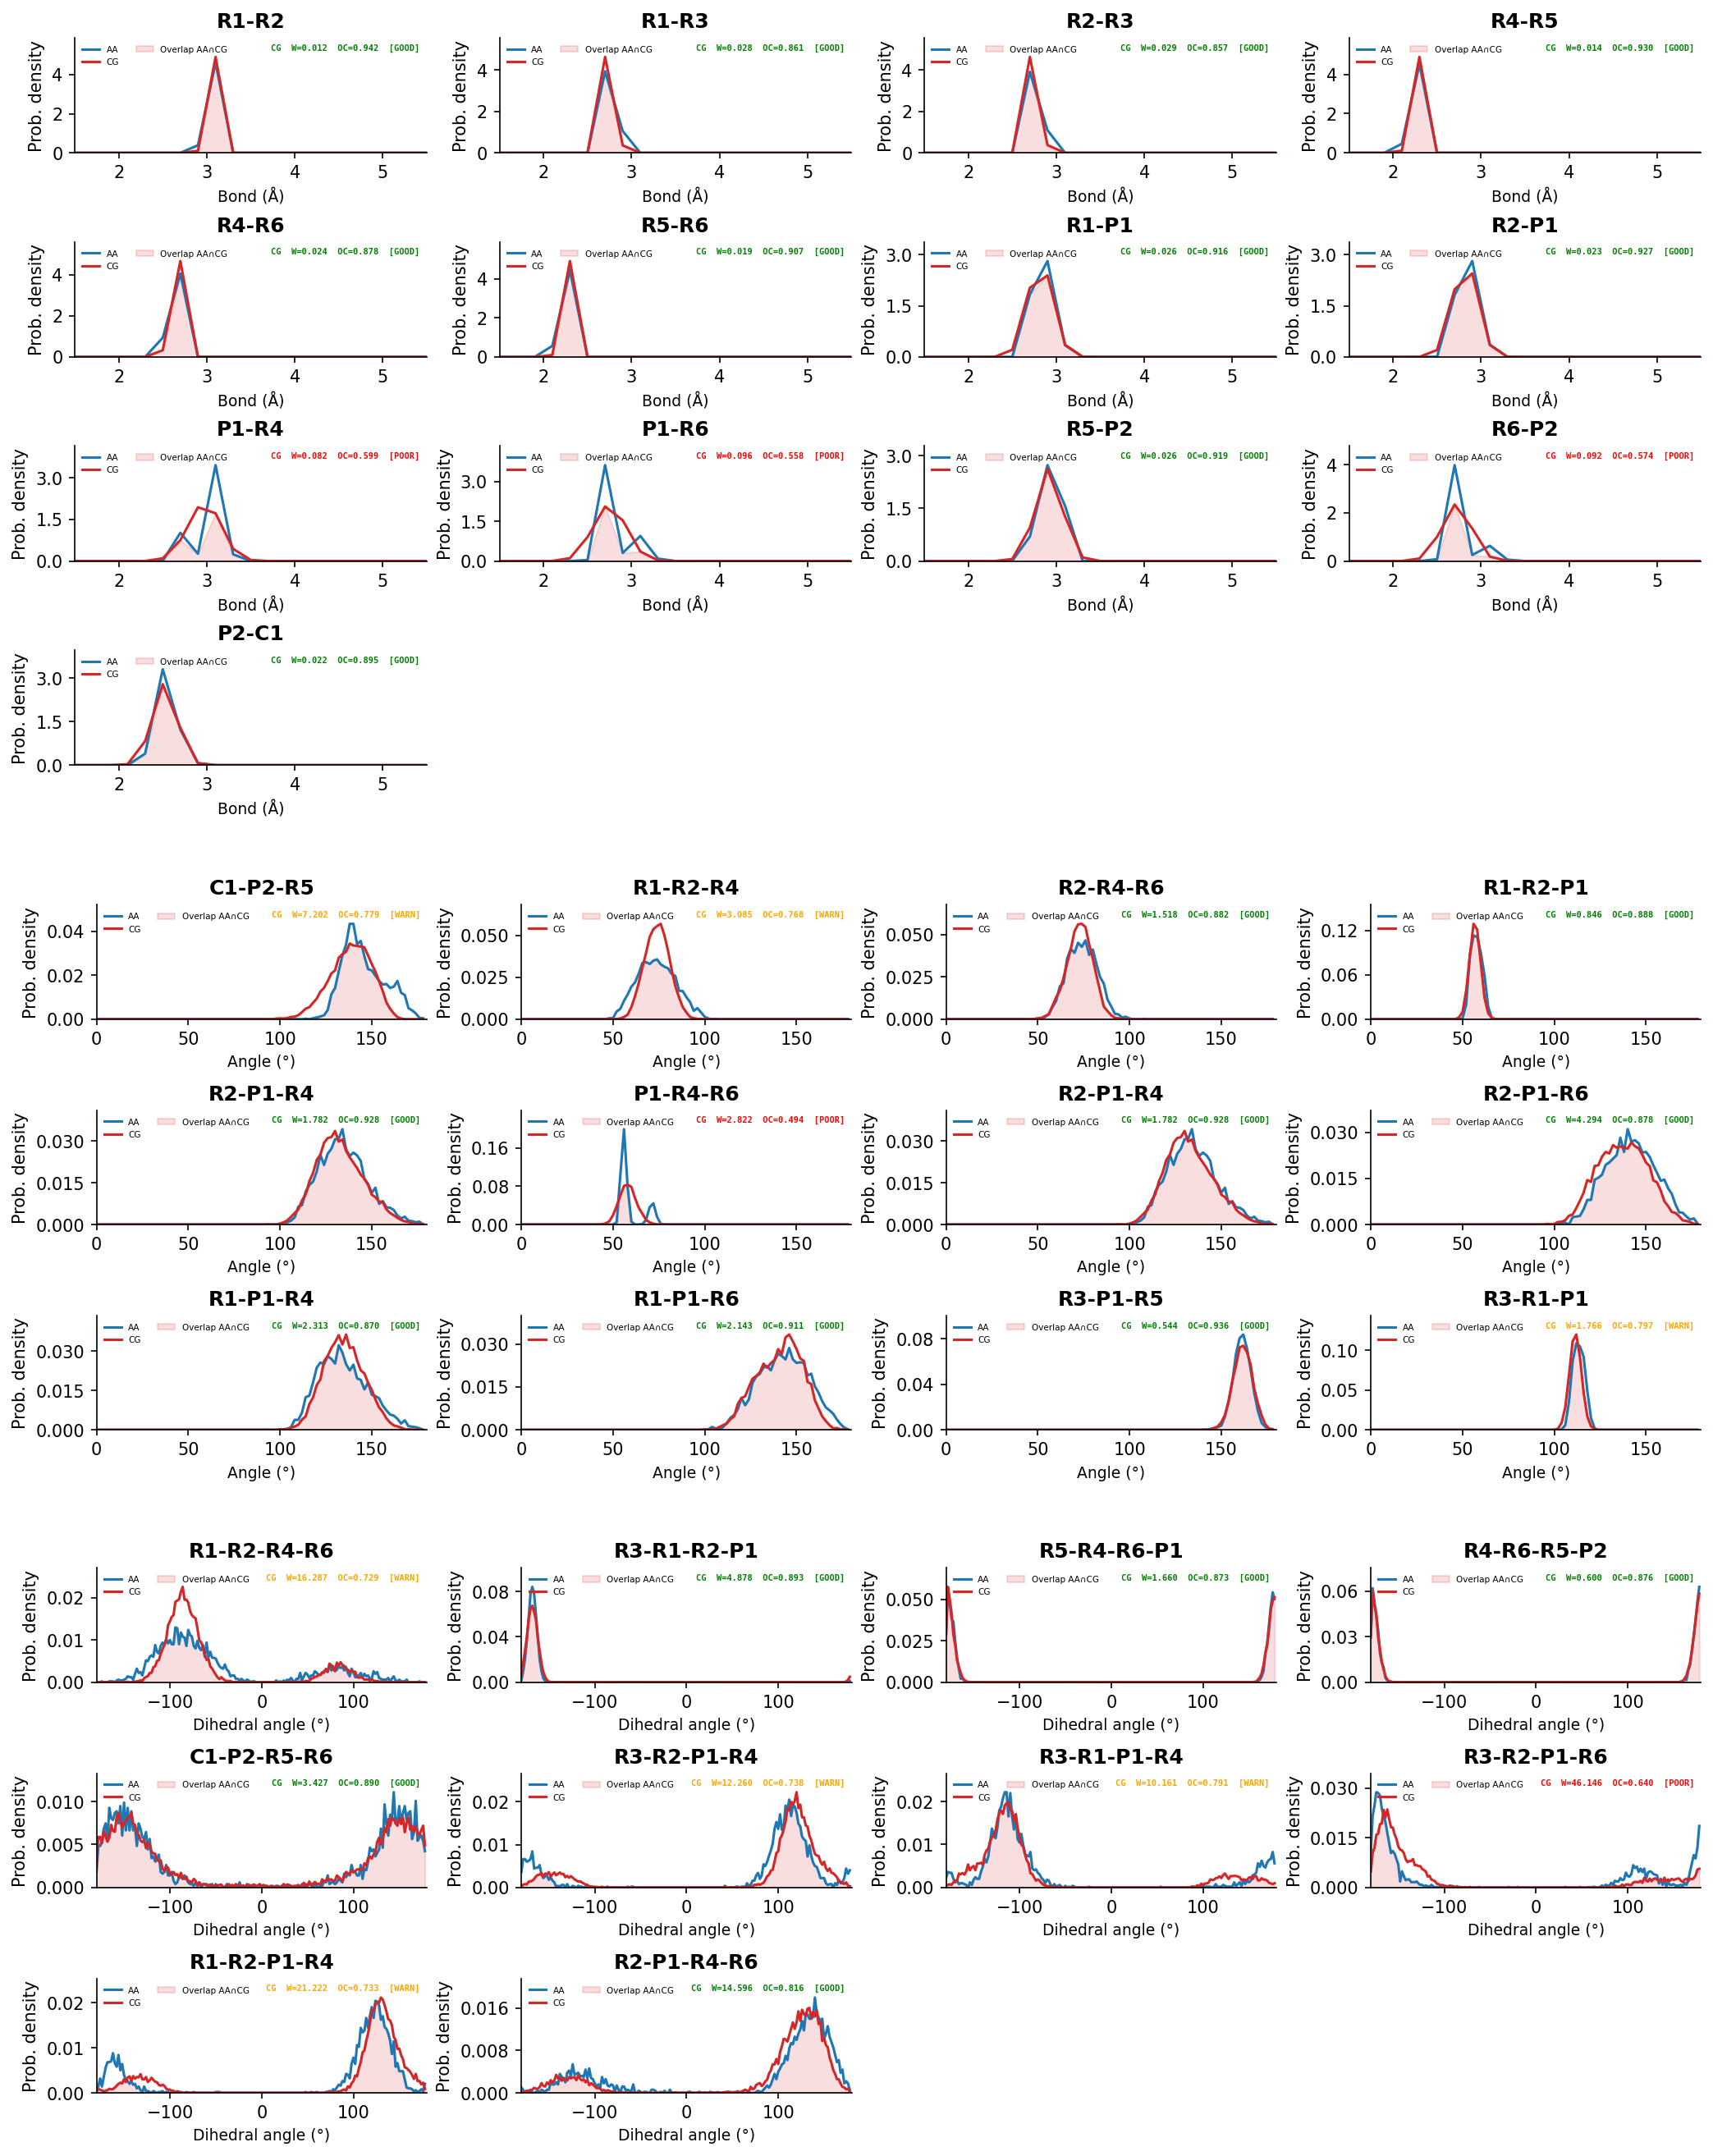

In [16]:
fig = shaker.plot_bonded_distributions(
            AA_bonded,
            CG_bonded,
            labels=["AA", "CG"],
            colors=["tab:blue", "tab:red"],
            outfile="cleanbonds")

#### 5.1. Recalculate SASA

It is also useful to routinely check the **SASA** of the CG simulated molecule during the optimization process. Changes to bonded parameters can alter the molecule’s average compactness and solvent exposure, which will be reflected in its SASA.

This can again be calculated using `shaker.sasa.run_SASA` and visualized with `shaker.plot.plot_sasa_dir`.

If the bonded parameters are defined correctly, the **CG simulated SASA** should closely match both the **CG-mapped trajectory** and the **AA reference**. Significant deviations may indicate that further refinement of the bonded parameters may still be required.


/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


CG_Simulated model is 91.57% of AA.


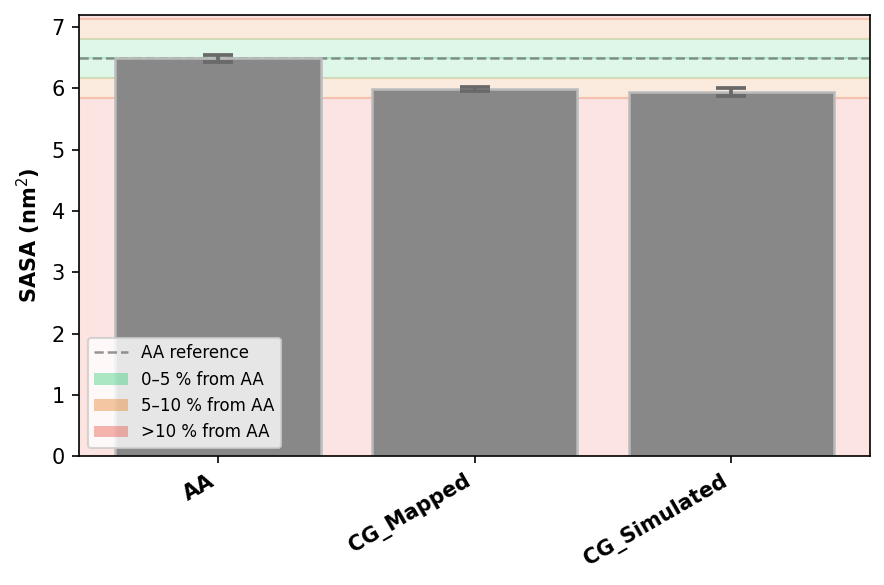

In [17]:
os.chdir(main_dir)
shaker.run_SASA('CG_Simulated',
                     f'{main_dir}/CG_WAT/pbc.pdb', f'{main_dir}/CG_WAT/pbc.xtc', resname, 
                     isCG=True, mapping=mapping)
fig, ax, sasa_values = shaker.plot_sasa_dir()

CG_over_AA_ratio = sasa_values[2][1] / sasa_values[0][1]
print(f"CG_Simulated model is {CG_over_AA_ratio:.2%} of AA.")

#### 5.2. Analyze molecule ensemble dynamics

Even after carefully optimizing bonded parameters, it is common to assume the parametrization is complete while some bonded terms remain incorrect. Small issues in angles or dihedrals, or even missing bonded potentials that were not initially considered may not be immediately obvious when inspecting individual distributions, but they can significantly affect the molecule's overall conformational behavior. For this reason, it is often useful to evaluate the **ensemble of conformations** sampled during the simulation rather than focusing only on individual bonded terms.

A simple way to do this is to visualize many frames from the trajectory at once. This allows us to qualitatively assess the **range of conformations**, **flexibility**, and **accessible degrees of freedom** of the molecule. `shaker.render.render_ensemble` provides a convenient way to do this. The function centers and aligns the molecule of interest and renders `n_frames` sampled from the trajectory for both the **CG-mapped atomistic trajectory** and the **CG simulation trajectory**. By comparing these two ensembles, we can quickly determine whether the CG model reproduces the conformational space observed in the mapped atomistic reference. If the bonded parameters are well parameterized, both ensembles should display **similar structural variability, flexibility, and overall conformational distributions**. Significant differences — such as overly restricted motion or unrealistic conformations — indicate that some bonded parameters may still require refinement.


In [18]:
## AA
shaker.render_ensemble('./CG_WAT/pbc.pdb', './cg_mapped.xtc',
                                sel="name P1 R4 R5 R6 P2",
                                n_frames=100
                                , size="400px")

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


NGLWidget()

In [19]:
## CG
shaker.render_ensemble('./CG_WAT/pbc.pdb', './CG_WAT/pbc.xtc',
                                sel="name P1 R4 R5 R6 P2",
                                n_frames=100
                                , size="400px")

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


NGLWidget()


For a more quantitative assessment, `shaker.assess_overlap_matrix` provides a complementary metric that goes beyond individual bonded terms. Rather than evaluating bonds, angles, and dihedrals in isolation, it measures the pairwise distance distributions between every bead in the molecule, capturing the **emergent 3D shape** of the residue as sampled across the trajectory. For each bead pair, the overlap coefficient between the AA and CG distributions is computed as:

$$OC = \int \min(p_{AA}(x),\ p_{CG}(x))\ dx$$

The result is an $N \times N$ matrix where each cell reports how well the CG model reproduces the distance distribution between two beads, with values ranging from 0 (no overlap) to 1 (identical distributions). A per-bead mean is appended to the right of the matrix, providing an at-a-glance summary of which beads are well reproduced and which may require further refinement. This metric is particularly sensitive to errors that bonded distributions alone may miss — a molecule can have individually correct bond and angle distributions yet still sample the wrong global shape if dihedral terms are poorly parameterized or if key interactions are absent.

Together, the ensemble visualization and the overlap matrix provide both a qualitative and quantitative picture of how well the CG model captures the structural behavior of the reference AA system.

Measuring intra-bead distances:   0%|          | 0/2501 [00:00<?, ?it/s]

Measuring intra-bead distances:   0%|          | 0/10001 [00:00<?, ?it/s]

/local/lborge01/gitbuilds/Shaker/shaker/overlap.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


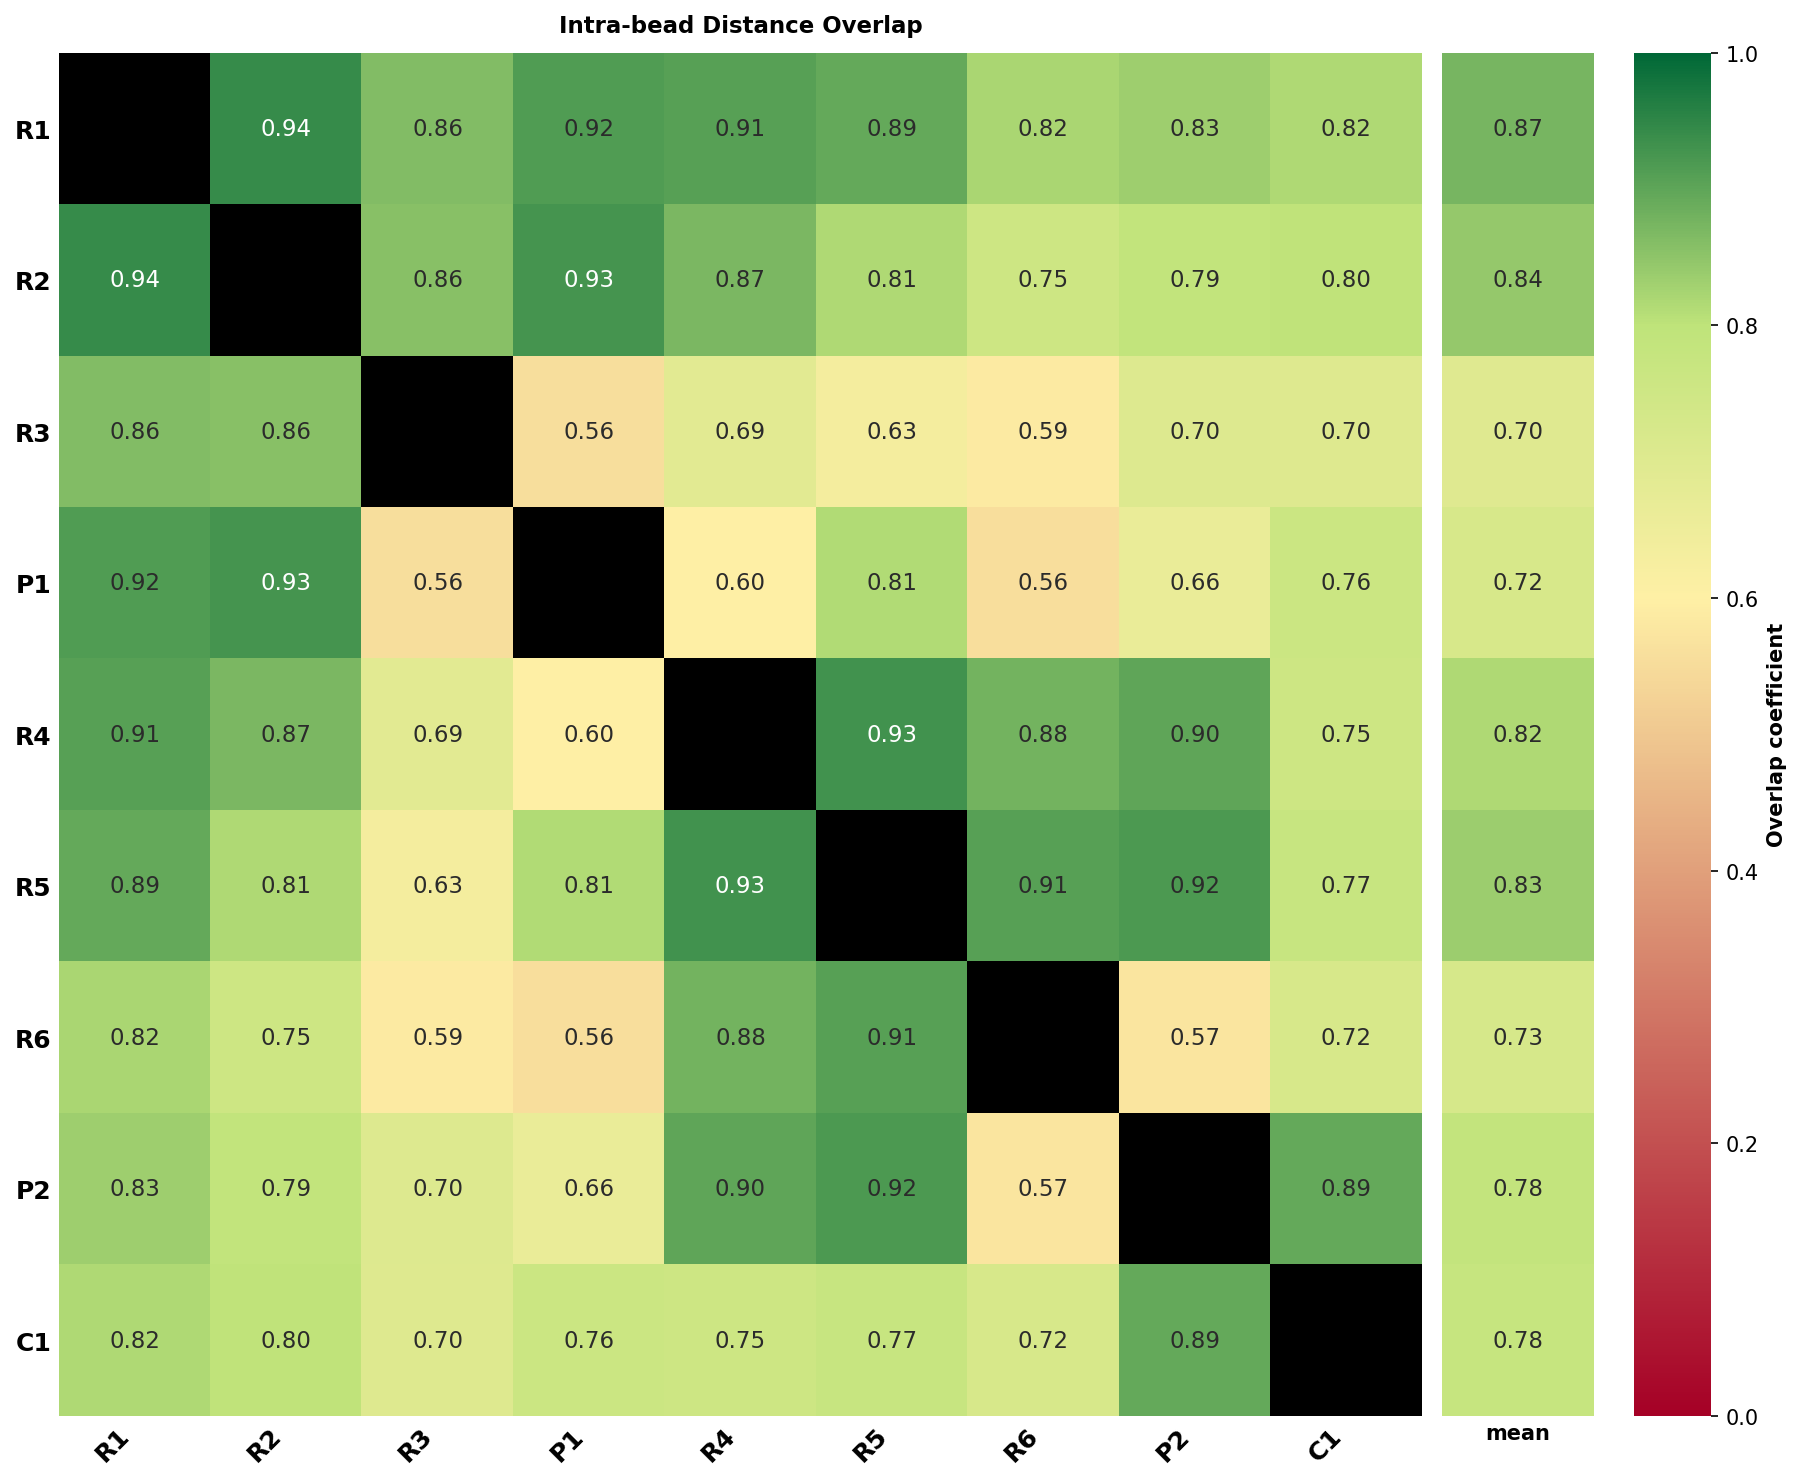

In [20]:
oc, fig, axes = shaker.assess_overlap_matrix(u_aa, u_cg, resname=resname)